# Relaxation Method

converged


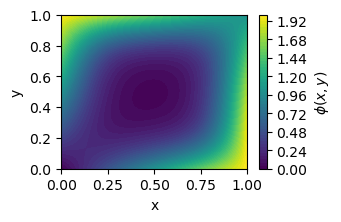

In [26]:
import numpy as np
import matplotlib.pyplot as plt

Nx = 100
Ny = 100

x_end = 1
y_end = 1

x = np.linspace(0, x_end, Nx)
y = np.linspace(0, y_end, Ny)

phi = np.zeros((Nx, Ny))

phi[:, 0] = 2*x # phi(x, 0) = 2x
phi[:, -1] = 2 - x # phi(x, y_end) = 2 - x
phi[0, :] = 2 * y # phi(0, y) = 2y
phi[-1, :] = 2 - y**2 # phi(x_end, y) = 2 - y^2

phi[0, 0] = 0
phi[-1, 0] = 2
phi[0, -1] = 2
phi[-1, -1] = 1

phi_new = np.copy(phi)

n_iterations = 1000
error = 1e-3

for n in range(n_iterations):
    phi_old = np.copy(phi)

    for i in range(1, Nx-1):
        for j in range(1, Ny-1):
            phi[i, j] = 0.25 * (phi_old[i+1, j] + phi_old[i-1, j]
                                + phi_old[i, j+1] + phi_old[i, j-1])
            
    diff = np.max(np.abs(phi - phi_old))
    if diff < error:
        print('converged')
        break

else:
    print('no convergence')

plt.figure(figsize=(3, 2))
plt.contourf(x, y, phi.T, cmap='viridis', levels=50)
plt.colorbar(label=r'$\phi(x,y)$')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Over-Relaxation

Converged after 69 iterations


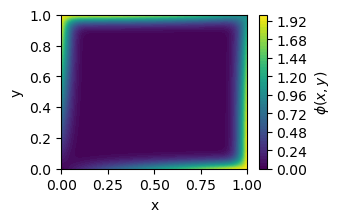

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Nx = 100
Ny = 100

x_end = 1
y_end = 1

x = np.linspace(0, x_end, Nx)
y = np.linspace(0, y_end, Ny)

phi = np.zeros((Nx, Ny))

phi[:, 0]  = 2 * x        # phi(x, 0)     = 2x
phi[:, -1] = 2 - x**2     # phi(x, y_end) = 2 - x^2
phi[0, :]  = 2 * y        # phi(0, y)     = 2y
phi[-1, :] = 2 - y**2     # phi(x_end, y) = 2 - y^2

phi[0, 0]   = 0
phi[-1, 0]  = 2
phi[0, -1]  = 2
phi[-1, -1] = 1

n_iterations = 1000
error = 1e-2

omega = 0.7

for n in range(n_iterations):
    phi_old = np.copy(phi)

    for i in range(1, Nx - 1):
        for j in range(1, Ny - 1):
            phi_jac = 0.25 * (phi_old[i+1, j] + phi_old[i-1, j]
                            + phi_old[i, j+1] + phi_old[i, j-1])
            phi[i, j] = (1 - omega) * phi_old[i, j] + omega * phi_jac

    diff = np.max(np.abs(phi - phi_old))
    if diff < error:
        print(f'Converged after {n+1} iterations')
        break

else:
    print('No convergence')

plt.figure(figsize=(3, 2))
plt.contourf(x, y, phi.T, cmap='viridis', levels=50)
plt.colorbar(label=r'$\phi(x,y)$')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Gauss-Seidel Method

Converged after 69 iterations


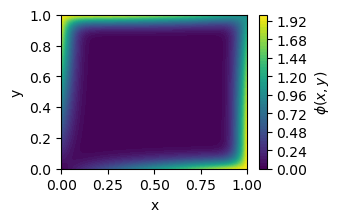

In [35]:
import numpy as np
import matplotlib.pyplot as plt

Nx = 100
Ny = 100

x_end = 1
y_end = 1

x = np.linspace(0, x_end, Nx)
y = np.linspace(0, y_end, Ny)

phi = np.zeros((Nx, Ny))

phi[:, 0]  = 2 * x        # phi(x, 0)     = 2x
phi[:, -1] = 2 - x**2     # phi(x, y_end) = 2 - x^2
phi[0, :]  = 2 * y        # phi(0, y)     = 2y
phi[-1, :] = 2 - y**2     # phi(x_end, y) = 2 - y^2

phi[0, 0]   = 0
phi[-1, 0]  = 2
phi[0, -1]  = 2
phi[-1, -1] = 1

n_iterations = 1000
error = 1e-2

omega = 0.7

for n in range(n_iterations):
    phi_old = np.copy(phi)

    for i in range(1, Nx - 1):
        for j in range(1, Ny - 1):
            phi_jac = 0.25 * (phi_old[i+1, j] + phi[i-1, j]
                            + phi_old[i, j+1] + phi[i, j-1])
            phi[i, j] = (1 - omega) * phi_old[i, j] + omega * phi_jac

    diff = np.max(np.abs(phi - phi_old))
    if diff < error:
        print(f'Converged after {n+1} iterations')
        break

else:
    print('No convergence')

plt.figure(figsize=(3, 2))
plt.contourf(x, y, phi.T, cmap='viridis', levels=50)
plt.colorbar(label=r'$\phi(x,y)$')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# FTCS Scheme

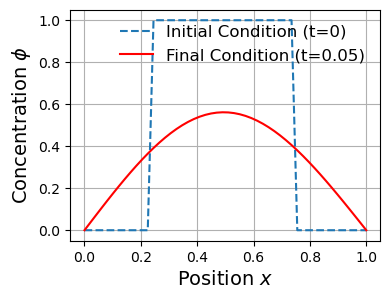

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
L = 1.0          # Length of the spatial domain
T = 0.05         # Total simulation time
D = 1.0          # Diffusion coefficient
Nx = 50          # Number of spatial grid points
Nt = 1000        # Number of time steps

# Grid spacing and time step 
a = L / (Nx - 1)
h = T / Nt

# --- Von Neumann Stability ---
# FTCS method for diffusion requires h <= a^2 / (2D)
if h > (a**2) / (2 * D):
    raise ValueError("The FTCS scheme is unstable with these parameters.")

# --- Initialization ---
x = np.linspace(0, L, Nx)
phi = np.zeros(Nx)

# Initial condition: A block of high concentration in the middle
phi[int(Nx/4) : int(3*Nx/4)] = 1.0
phi_initial = phi.copy() # Save for plotting later

# --- FTCS Time-Stepping Loop ---
for n in range(Nt):

    phi[1:-1] = phi[1:-1] + h * (D / a**2) * (phi[2:] - 2*phi[1:-1] + phi[:-2])
    
    # Boundary conditions 
    phi[0] = 0.0
    phi[-1] = 0.0

# --- Plotting ---
plt.figure(figsize=(4, 3))
plt.plot(x, phi_initial, label='Initial Condition (t=0)', ls='--')
plt.plot(x, phi, label=f'Final Condition (t={T})', color='r')
plt.xlabel(r'Position $x$', fontsize=14)
plt.ylabel(r'Concentration $\phi$', fontsize=14)
plt.legend(frameon=False, fontsize=12)
plt.grid(True)
plt.show()

# Implicit and Crank-Nicholson Methods

In [ ]:
import numpy as np
from scipy.linalg import solve_banded

def implicit(phi_0, psi_0, v, a, h, Nt):
   
    Nx = len(phi_0)
    
    # Constant C^2 based on the implicit equation substitution
    C2 = (h * v / a)**2

    # Construct the tridiagonal matrix for the left-hand side
    # scipy's solve_banded requires a specific matrix shape (upper, main, lower diagonals)
    A_banded = np.zeros((3, Nx - 2))
    A_banded[0, 1:] = -C2                # Upper diagonal
    A_banded[1, :]  = 1 + 2 * C2         # Main diagonal
    A_banded[2, :-1] = -C2               # Lower diagonal

    # Initialize variables
    phi = phi_0.copy()
    psi = psi_0.copy()

    for _ in range(Nt):
        # Calculate the RHS for interior points
        rhs = phi[1:-1] + h * psi[1:-1]
        
        # Solve the simultaneous equations for phi at the next time step
        phi_next = np.zeros(Nx)
        phi_next[1:-1] = solve_banded((1, 1), A_banded, rhs)
        
        # Determine psi at the next time step using the implicit relationship
        psi_next = np.zeros(Nx)
        psi_next[1:-1] = (phi_next[1:-1] - phi[1:-1]) / h

        # Advance in time
        phi = phi_next
        psi = psi_next

    return phi, psi


def crank_nicholson(phi_0, psi_0, v, a, h, Nt):
   
    Nx = len(phi_0)
    
    # Constant based on the Crank-Nicolson averaged substitution
    C2_4 = ((h * v / a)**2) / 4.0

    # Construct the tridiagonal matrix for the left-hand side
    A_banded = np.zeros((3, Nx - 2))
    A_banded[0, 1:] = -C2_4              # Upper diagonal
    A_banded[1, :]  = 1 + 2 * C2_4       # Main diagonal
    A_banded[2, :-1] = -C2_4             # Lower diagonal

    # Initialize variables
    phi = phi_0.copy()
    psi = psi_0.copy()

    for _ in range(Nt):
        # Calculate the right-hand side for interior points
        # This includes spatial neighbors from the CURRENT time step t
        rhs = (C2_4 * phi[:-2] + 
               (1 - 2 * C2_4) * phi[1:-1] + 
               C2_4 * phi[2:] + 
               h * psi[1:-1])

        # Solve the simultaneous equations for phi at the next time step
        phi_next = np.zeros(Nx)
        phi_next[1:-1] = solve_banded((1, 1), A_banded, rhs)

        # Determine psi at the next time step 
        psi_next = np.zeros(Nx)
        psi_next[1:-1] = (2.0 / h) * (phi_next[1:-1] - phi[1:-1]) - psi[1:-1]

        # Advance in time
        phi = phi_next
        psi = psi_next

    return phi, psi